This notebook is used for data_preprocessing and model fitting

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from hmmlearn import hmm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,  accuracy_score,f1_score
from graphviz import Digraph
from graphviz import Source
from sklearn.model_selection import LeaveOneGroupOut
import matplotlib.patches as mpatches

#from hmmlearn.hmm import GaussianHMM


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
file_path = "../data/ConfLongDemo_JSI.txt"

# Load using comma separator
df = pd.read_csv(file_path, sep=",", header=None)

print(df.head())
print(df.shape)

     0                1                   2                        3  \
0  A01  010-000-024-033  633790226051280329  27.05.2009 14:03:25:127   
1  A01  020-000-033-111  633790226051820913  27.05.2009 14:03:25:183   
2  A01  020-000-032-221  633790226052091205  27.05.2009 14:03:25:210   
3  A01  010-000-024-033  633790226052361498  27.05.2009 14:03:25:237   
4  A01  010-000-030-096  633790226052631792  27.05.2009 14:03:25:263   

          4         5         6        7  
0  4.062931  1.892434  0.507425  walking  
1  4.291954  1.781140  1.344495  walking  
2  4.359101  1.826456  0.968821  walking  
3  4.087835  1.879999  0.466983  walking  
4  4.324462  2.072460  0.488065  walking  
(164860, 8)


In [4]:
df.columns = [
    "sequence_name",      # A01–E05 (person/session)
    "tag_id",             # sensor ID
    "timestamp",          # numeric unique timestamp
    "date_time",          # formatted date
    "x",                  # x coordinate
    "y",                  # y coordinate
    "z",                  # z coordinate
    "activity"            # activity label
]

In [5]:
print(df.head(30))

   sequence_name           tag_id           timestamp  \
0            A01  010-000-024-033  633790226051280329   
1            A01  020-000-033-111  633790226051820913   
2            A01  020-000-032-221  633790226052091205   
3            A01  010-000-024-033  633790226052361498   
4            A01  010-000-030-096  633790226052631792   
5            A01  020-000-033-111  633790226052902087   
6            A01  020-000-032-221  633790226053172379   
7            A01  010-000-024-033  633790226053442677   
8            A01  020-000-033-111  633790226053983265   
9            A01  010-000-024-033  633790226054523854   
10           A01  010-000-030-096  633790226054794151   
11           A01  020-000-033-111  633790226055064446   
12           A01  020-000-032-221  633790226055334743   
13           A01  010-000-024-033  633790226055605037   
14           A01  020-000-032-221  633790226056415915   
15           A01  010-000-024-033  633790226056686205   
16           A01  010-000-030-0

In [6]:
df.isnull().sum()

sequence_name    0
tag_id           0
timestamp        0
date_time        0
x                0
y                0
z                0
activity         0
dtype: int64

In [7]:
#Covert date_time to datetime format
df["date_time"] = pd.to_datetime(df["date_time"], format="%d.%m.%Y %H:%M:%S:%f")
df[["x", "y", "z"]] = df[["x", "y", "z"]].astype(float)

In [8]:
# Sort the dataset by participant and timestamp
df = df.sort_values(['sequence_name', 'date_time']).reset_index(drop=True)


In [9]:
#Check each participant's data
for participant in df['sequence_name'].unique():
    print(f"Participant: {participant}")
    print(df[df['sequence_name'] == participant].head())
    print()

Participant: A01
  sequence_name           tag_id           timestamp               date_time  \
0           A01  010-000-024-033  633790226051280329 2009-05-27 14:03:25.127   
1           A01  020-000-033-111  633790226051820913 2009-05-27 14:03:25.183   
2           A01  020-000-032-221  633790226052091205 2009-05-27 14:03:25.210   
3           A01  010-000-024-033  633790226052361498 2009-05-27 14:03:25.237   
4           A01  010-000-030-096  633790226052631792 2009-05-27 14:03:25.263   

          x         y         z activity  
0  4.062931  1.892434  0.507425  walking  
1  4.291954  1.781140  1.344495  walking  
2  4.359101  1.826456  0.968821  walking  
3  4.087835  1.879999  0.466983  walking  
4  4.324462  2.072460  0.488065  walking  

Participant: A02
     sequence_name           tag_id           timestamp  \
5830           A02  010-000-024-033  633790230241677177   
5831           A02  010-000-030-096  633790230241947475   
5832           A02  020-000-033-111  633790230242

In [10]:
#Check the timestamp gaps per participant
for participant, group in df.groupby("sequence_name"):
    
    # Compute gaps in milliseconds
    gaps = group['date_time'].diff().dropna().dt.total_seconds() * 1000
    
    print(f"Participant {participant}:")
    print(f"  Min gap: {gaps.min():.1f} ms")
    print(f"  Max gap: {gaps.max():.1f} ms")
    print(f"  Median gap: {gaps.median():.1f} ms")
    print("-" * 40)

Participant A01:
  Min gap: 0.0 ms
  Max gap: 137.0 ms
  Median gap: 27.0 ms
----------------------------------------
Participant A02:
  Min gap: 17.0 ms
  Max gap: 136.0 ms
  Median gap: 27.0 ms
----------------------------------------
Participant A03:
  Min gap: 4.0 ms
  Max gap: 137.0 ms
  Median gap: 27.0 ms
----------------------------------------
Participant A04:
  Min gap: 0.0 ms
  Max gap: 110.0 ms
  Median gap: 27.0 ms
----------------------------------------
Participant A05:
  Min gap: 16.0 ms
  Max gap: 133.0 ms
  Median gap: 27.0 ms
----------------------------------------
Participant B01:
  Min gap: 16.0 ms
  Max gap: 136.0 ms
  Median gap: 27.0 ms
----------------------------------------
Participant B02:
  Min gap: 16.0 ms
  Max gap: 110.0 ms
  Median gap: 27.0 ms
----------------------------------------
Participant B03:
  Min gap: 0.0 ms
  Max gap: 164.0 ms
  Median gap: 27.0 ms
----------------------------------------
Participant B04:
  Min gap: 0.0 ms
  Max gap: 160.0 

In [11]:
#Check sensor time allowance by comparing timestamps of one reference sensor to others
# Reference sensor
ref_tag = "010-000-024-033"
other_tags = [t for t in df["tag_id"].unique() if t != ref_tag]

# Filter only one sequence for simplicity
seq = "A01"
df_seq = df[df["sequence_name"] == seq]

# Get timestamps of reference sensor
ref_ts = df_seq[df_seq["tag_id"] == ref_tag]["date_time"].sort_values().reset_index(drop=True)

# Check nearest timestamp differences for each other sensor
for tag in other_tags:
    other_ts = df_seq[df_seq["tag_id"] == tag]["date_time"].sort_values().reset_index(drop=True)
    
    # Compute nearest time differences
    diffs = []
    for t in other_ts:
        nearest = ref_ts.sub(t).abs().min()
        diffs.append(nearest.total_seconds() * 1000)  # in ms
    
    diffs = np.array(diffs)
    print(f"{tag} → min: {diffs.min():.2f} ms, max: {diffs.max():.2f} ms, mean: {diffs.mean():.2f} ms, 95%: {np.percentile(diffs, 95):.2f} ms")

020-000-033-111 → min: 26.00 ms, max: 163.00 ms, mean: 53.43 ms, 95%: 54.00 ms
020-000-032-221 → min: 17.00 ms, max: 137.00 ms, mean: 30.37 ms, 95%: 80.00 ms
010-000-030-096 → min: 17.00 ms, max: 137.00 ms, mean: 30.08 ms, 95%: 60.00 ms


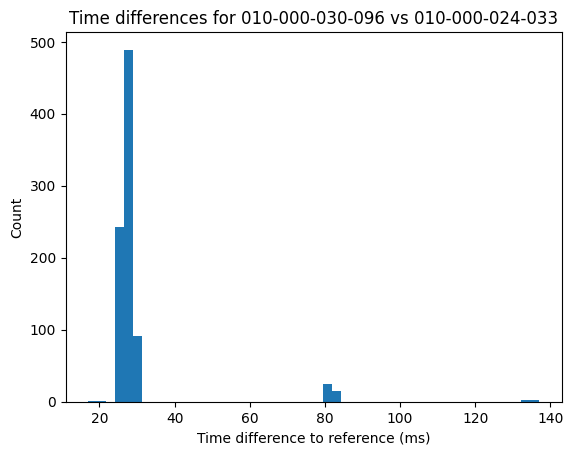

In [12]:
plt.hist(diffs, bins=50)
plt.xlabel("Time difference to reference (ms)")
plt.ylabel("Count")
plt.title(f"Time differences for {tag} vs {ref_tag}")
plt.show()

In [13]:
#Map tag ids to body parts
tag_map = {
    "010-000-024-033": "ANKLE_LEFT",
    "010-000-030-096": "ANKLE_RIGHT",
    "020-000-033-111": "CHEST",
    "020-000-032-221": "BELT"
}

df["body_position"] = df["tag_id"].map(tag_map)

In [14]:
#check activity distribution
print(df["activity"].value_counts())

activity
lying                                     54480
walking                                   32710
sitting                                   27244
standing up from lying                    18361
sitting on the ground                     11779
lying down                                 6168
on all fours                               5210
falling                                    2973
standing up from sitting on the ground     2848
sitting down                               1706
standing up from sitting                   1381
Name: count, dtype: int64


In [15]:
#Creat binary label for fall/not fall
df["label"] = df["activity"].apply(
    lambda x: 1 if x == "falling" else 0
)

In [16]:
df.head()

,sequence_name,tag_id,timestamp,date_time,x,y,z,activity,body_position,label
0,A01,010-000-024-033,633790226051280329,2009-05-27 14:03:25.127,4.062931,1.892434,0.507425,walking,ANKLE_LEFT,0
1,A01,020-000-033-111,633790226051820913,2009-05-27 14:03:25.183,4.291954,1.781140,1.344495,walking,CHEST,0
2,A01,020-000-032-221,633790226052091205,2009-05-27 14:03:25.210,4.359101,1.826456,0.968821,walking,BELT,0
3,A01,010-000-024-033,633790226052361498,2009-05-27 14:03:25.237,4.087835,1.879999,0.466983,walking,ANKLE_LEFT,0
4,A01,010-000-030-096,633790226052631792,2009-05-27 14:03:25.263,4.324462,2.072460,0.488065,walking,ANKLE_RIGHT,0


In [17]:
#Create magnitude of acceleration as a new feature
df["acc_mag"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

Check the between/within participant variance

In [18]:
# Filter only one activity, e.g., walking
df_walk = df[df["activity"] == "walking"]

# Mean per participant
person_means = df_walk.groupby("sequence_name")["acc_mag"].mean()

# Global mean
global_mean = df_walk["acc_mag"].mean()

# Between-person variance
between_var = np.var(person_means, ddof=1)

# Within-person variance (average)
within_var = df_walk.groupby("sequence_name")["acc_mag"].var().mean()

print("Global Mean:", global_mean)
print("Between-person variance:", between_var)
print("Within-person variance:", within_var)
print("Ratio (Between / Within):", between_var / within_var)

Global Mean: 3.273675821225736
Between-person variance: 0.03531148185851412
Within-person variance: 0.45574275508719
Ratio (Between / Within): 0.07748116994587997


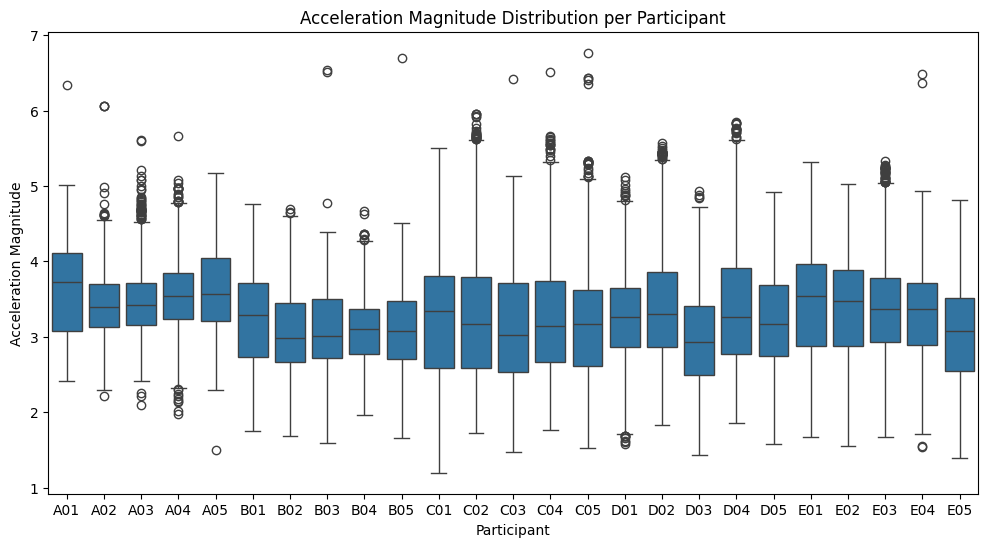

In [19]:
# Boxplot of acceleration magnitude by participant
plt.figure(figsize=(12,6))
sns.boxplot(x='sequence_name', y='acc_mag', data=df_walk)
plt.title('Acceleration Magnitude Distribution per Participant')
plt.ylabel('Acceleration Magnitude')
plt.xlabel('Participant')
plt.show()

In [20]:
sensor_means = df_walk.groupby("tag_id")["acc_mag"].mean()
between_sensor_var = np.var(sensor_means, ddof=1)
within_sensor_var = df_walk.groupby("tag_id")["acc_mag"].var().mean()
print("Between-sensor variance:", between_sensor_var)
print("Within-sensor variance:", within_sensor_var)
print("Sensor Ratio:", between_sensor_var / within_sensor_var)

Between-sensor variance: 0.010981807692032539
Within-sensor variance: 0.4864903569760313
Sensor Ratio: 0.02257353621620417


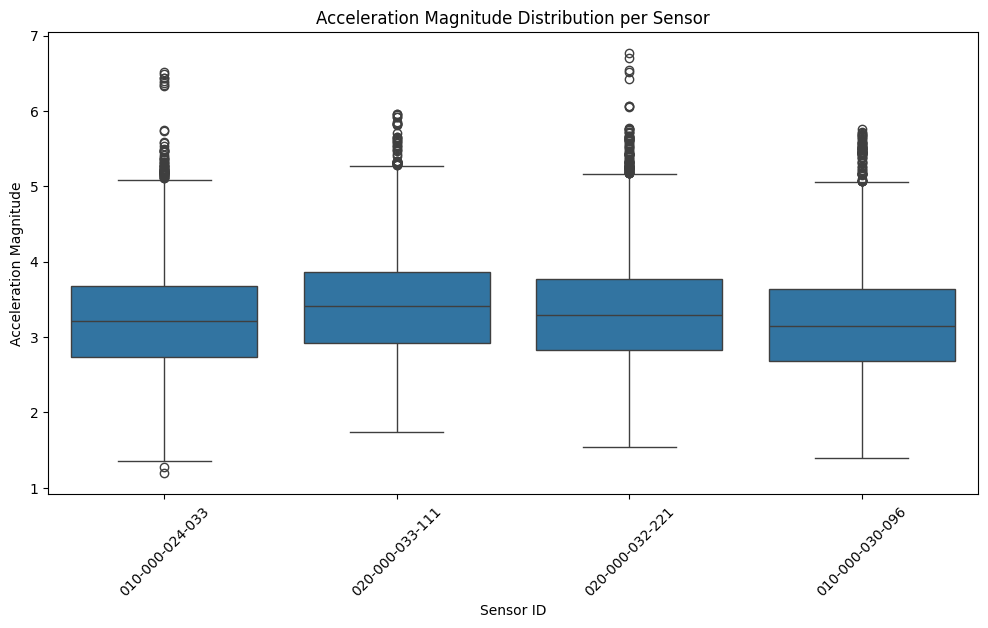

In [21]:
# Boxplot of acceleration magnitude by sensor
plt.figure(figsize=(12,6))
sns.boxplot(x='tag_id', y='acc_mag', data=df_walk)
plt.xticks(rotation=45)
plt.title('Acceleration Magnitude Distribution per Sensor')
plt.ylabel('Acceleration Magnitude')
plt.xlabel('Sensor ID')
plt.show()

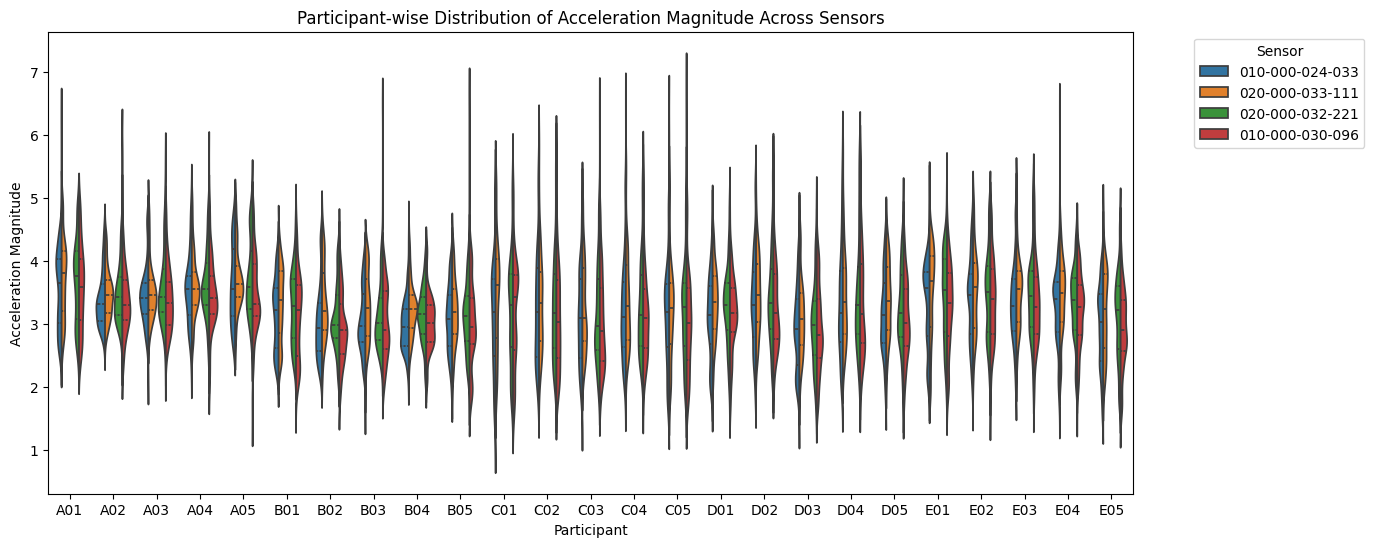

In [22]:
# Violin plot showing both participant and sensor
plt.figure(figsize=(14,6))
sns.violinplot(x='sequence_name', y='acc_mag', hue='tag_id', data=df_walk, split=True, inner='quartile')
plt.title('Participant-wise Distribution of Acceleration Magnitude Across Sensors')
plt.ylabel('Acceleration Magnitude')
plt.xlabel('Participant')
plt.legend(title='Sensor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [23]:
# Split sequences into train/test
sequence_names = df['sequence_name'].unique()
train_seqs, test_seqs = train_test_split(sequence_names, test_size=0.2, random_state=42)

train_df = df[df['sequence_name'].isin(train_seqs)].reset_index(drop=True)
test_df = df[df['sequence_name'].isin(test_seqs)].reset_index(drop=True)

print(f"Train sequences: {len(train_seqs)}, Test sequences: {len(test_seqs)}")
print(f"Train data shape: {train_df.shape}, Test data shape: {test_df.shape}")


Train sequences: 20, Test sequences: 5
Train data shape: (132095, 11), Test data shape: (32765, 11)


## **MODEL BUILDING**



### **A. Participants-Level Approach**

### 1. Hierarchical HMM with Acceleration Magnitude (participant-level)


We first built a basedline Hierarchical HMM: P(O(k)∣nested HMM) initialized by P(O∣global HMM), using acceleration magnitude

Concatenate all sequences → fit global HMM → estimate HMM parameters;

For each participant → initialize nested HMM with global parameters → fit to that participant's data → capture personal variation

In [24]:
# Standardize the acceleration magnitude
scaler = StandardScaler()
train_df['acc_mag_scaled'] = scaler.fit_transform(train_df[['acc_mag']])
test_df['acc_mag_scaled'] = scaler.transform(test_df[['acc_mag']]) 

feature_col = ['acc_mag_scaled']

In [25]:
#Prepare sequences for HMM
sequence_groups_train = train_df.groupby('sequence_name')
all_sequences_train = []
lengths_train = []

for seq_name, seq_df in sequence_groups_train:
    obs = seq_df[feature_col].values
    all_sequences_train.append(obs)
    lengths_train.append(len(obs))

all_sequences_concat_train = np.vstack(all_sequences_train)

In [26]:
#Fit HMM model
n_global_states = 3
global_hmm = hmm.GaussianHMM(
    n_components=n_global_states,
    covariance_type='diag',
    n_iter=200,
    random_state=42
)
global_hmm.fit(all_sequences_concat_train, lengths=lengths_train)

GaussianHMM(n_components=3, n_iter=200, random_state=42)

In [27]:
# Fit nested HMMs per train sequence
nested_hmms = {}
for seq_name, seq_df in sequence_groups_train:
    obs = seq_df[feature_col].values
    seq_hmm = hmm.GaussianHMM(
        n_components=n_global_states,
        covariance_type='diag',
        n_iter=100,
        random_state=42,
        params='stmc'
    )
    seq_hmm.means_ = np.copy(global_hmm.means_)
    seq_hmm.covars_ = np.copy(global_hmm.covars_).reshape(n_global_states, -1)
    seq_hmm.startprob_ = np.copy(global_hmm.startprob_)
    seq_hmm.transmat_ = np.copy(global_hmm.transmat_)
    seq_hmm.fit(obs)
    nested_hmms[seq_name] = seq_hmm

print(f"Fitted nested HMMs for {len(nested_hmms)} train sequences.")

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Fitted nested HMMs for 20 train sequences.


#### Baseline HMM Model Evaluation

In [28]:
# -------------------------------
# Step 1: Map hidden states -> fall (1) / no-fall (0) using train sequences
# -------------------------------
state_label_mapping = {}

for seq_name, seq_df in sequence_groups_train:
    obs = seq_df[feature_col].values.reshape(-1,1)
    hidden_states = nested_hmms[seq_name].predict(obs)
    seq_df = seq_df.copy()
    seq_df['hidden_state'] = hidden_states

    # Hidden state with highest mean acc_mag is "falling"
    mean_acc_per_state = seq_df.groupby('hidden_state')['acc_mag'].mean()
    falling_state = mean_acc_per_state.idxmax()

    # Map each hidden state to 0/1
    mapping = {s: (1 if s == falling_state else 0) for s in range(n_global_states)}
    state_label_mapping[seq_name] = mapping

# -------------------------------
# Step 2: Evaluate on test sequences
# -------------------------------
y_true_all = []
y_pred_all = []

sequence_groups_test = test_df.groupby('sequence_name')

for seq_name, seq_df in sequence_groups_test:
    obs = seq_df[feature_col].values.reshape(-1,1)

    # Use nested HMM if exists (train sequences), else fallback to global HMM
    hmm_model = nested_hmms.get(seq_name, global_hmm)

    hidden_states = hmm_model.predict(obs)

    # Map hidden states to fall/not-fall using the first train sequence mapping
    mapping = state_label_mapping.get(seq_name, state_label_mapping[train_seqs[0]])
    pred_labels = [mapping[s] for s in hidden_states]

    y_true_all.extend(seq_df['label'].values)
    y_pred_all.extend(pred_labels)

# -------------------------------
# Step 3: Compute metrics
# -------------------------------
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Confusion Matrix:\n", confusion_matrix(y_true_all, y_pred_all))
print("\nClassification Report:\n", classification_report(y_true_all, y_pred_all, zero_division=0))


Accuracy: 0.759560506638181
Confusion Matrix:
 [[24870  7357]
 [  521    17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.77      0.86     32227
           1       0.00      0.03      0.00       538

    accuracy                           0.76     32765
   macro avg       0.49      0.40      0.43     32765
weighted avg       0.96      0.76      0.85     32765



Mean acc_mag per hidden state per activity:
activity       falling     lying  lying down  on all fours   sitting  \
hidden_state                                                           
0             3.689655  3.595515    3.324802       0.00000  3.556125   
1             3.637591  3.599878    3.280529       0.00000  3.573213   
2             0.000000  2.356655    2.751656       2.13586  0.000000   

activity      sitting down  sitting on the ground  standing up from lying  \
hidden_state                                                                
0                 3.522728               4.033688                3.785826   
1                 3.529519               4.019331                3.728079   
2                 0.000000               0.000000                2.542480   

activity      standing up from sitting  \
hidden_state                             
0                             3.591767   
1                             3.586134   
2                             0.000000   

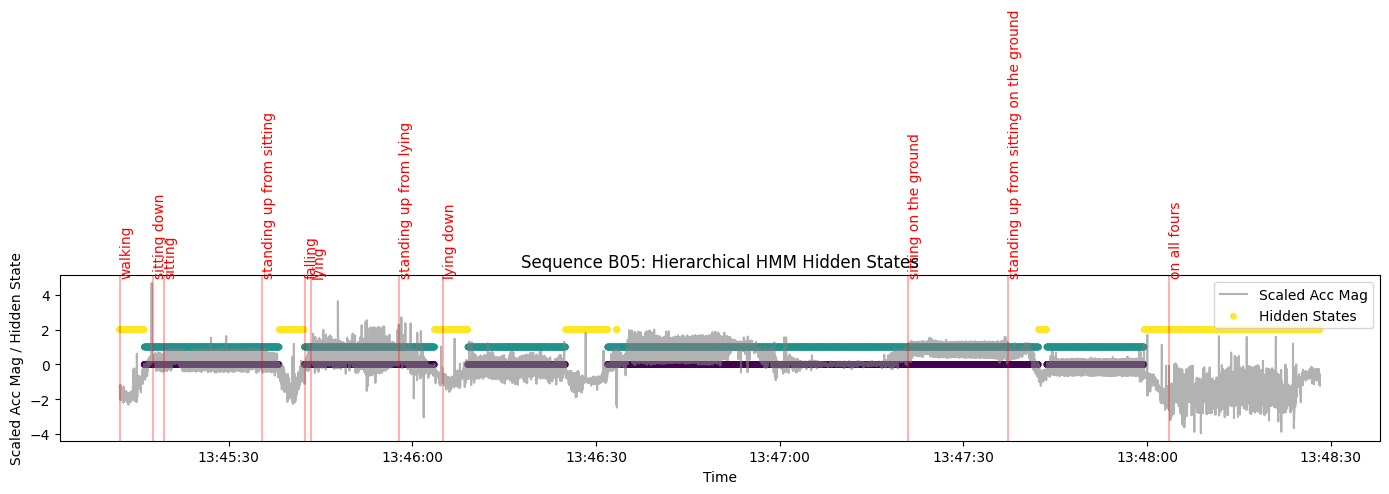

In [29]:
# visualize first train sequence

seq_name = train_seqs[0]  
df_seq = train_df[train_df['sequence_name'] == seq_name].copy()


# Use nested HMM if train, global HMM if test
if seq_name in nested_hmms:
    hmm_model = nested_hmms[seq_name]
else:
    hmm_model = global_hmm

obs = df_seq['acc_mag_scaled'].values.reshape(-1, 1)
hidden_states = hmm_model.predict(obs)
df_seq['hidden_state'] = hidden_states

# -----------------------------
# Map hidden states to activity by mean acc_mag
# -----------------------------
state_activity_map = df_seq.groupby(['hidden_state', 'activity'])['acc_mag'].mean().unstack(fill_value=0)
print("Mean acc_mag per hidden state per activity:")
print(state_activity_map)


plt.figure(figsize=(14,5))

# Acceleration magnitude line
plt.plot(df_seq['date_time'], df_seq['acc_mag_scaled'], label='Scaled Acc Mag', color='gray', alpha=0.6)

# Hidden states as scatter
plt.scatter(df_seq['date_time'], df_seq['hidden_state'], c=df_seq['hidden_state'],
            cmap='viridis', s=15, label='Hidden States')

# Mark activity transitions
for act in df_seq['activity'].unique():
    act_df = df_seq[df_seq['activity'] == act]
    start_time = act_df['date_time'].iloc[0]
    plt.axvline(x=start_time, color='red', alpha=0.3)
    plt.text(start_time, df_seq['acc_mag_scaled'].max()*1.05, act,
             rotation=90, verticalalignment='bottom', color='red', fontsize=10)

plt.title(f'Sequence {seq_name}: Hierarchical HMM Hidden States')
plt.xlabel('Time')
plt.ylabel('Scaled Acc Mag / Hidden State')
plt.legend()
plt.tight_layout()
plt.show()

This hidden states are capturing different intensity levels:

State 0: Moderate acceleration — appears in mostly static or low-movement activities like lying, sitting, and some “standing up from sitting” movements.

State 1: Slightly higher acceleration — likely captures subtle transitions or medium-intensity movements like sitting, standing up, or walking start/stop.

State 2: Lowest/highly selective acceleration — it has zero values for many activities but appears for specific movements like walking, standing up from lying, or on all fours.

However, HMMs model patterns in the signal, not the explicit activity label. We might need a classifier on top of hidden states for exact activity recognition. 

Also HMM model failed to detect falls, introduce more features might help


### 2. Multi-features HMM model (Participant level)

We fitted a multi-features heriat model where we use the Global HMM captures general activity patterns across all participants, then nested HMMs adapt this knowledge to individual sequences, improving classification.

​Global HMM: P(X1:Tall​​∣θ global​)
Nested HMM per sequence i:P(X1:Ti​(i)​∣θ nested(i)​)

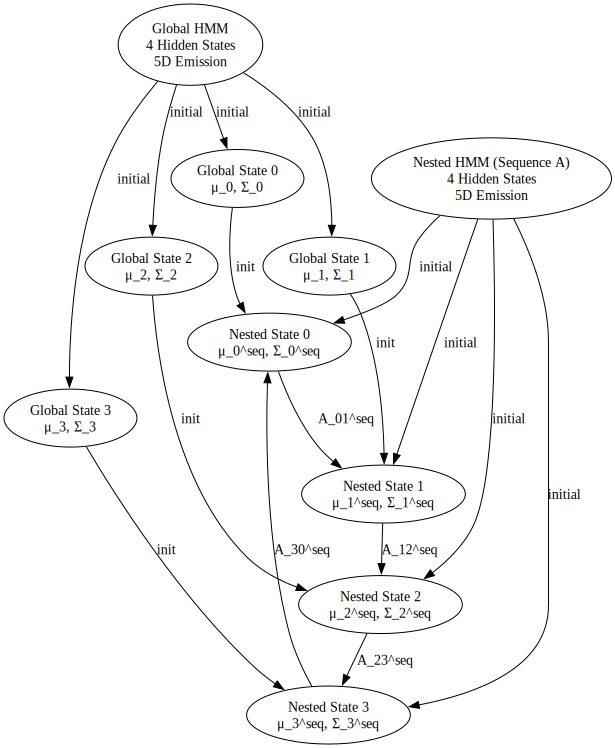

In [30]:
from graphviz import Digraph, Source

# Create the graph
dot = Digraph(comment='Global → Nested HMM')

# Global HMM
dot.node('G', 'Global HMM\n4 Hidden States\n5D Emission')

# Add global states
for i in range(4):
    dot.node(f'G{i}', f'Global State {i}\nμ_{i}, Σ_{i}')
    dot.edge('G', f'G{i}', label='initial')

# Nested HMM for a single sequence
dot.node('S', 'Nested HMM (Sequence A)\n4 Hidden States\n5D Emission')

for i in range(4):
    dot.node(f'S{i}', f'Nested State {i}\nμ_{i}^seq, Σ_{i}^seq')
    dot.edge('S', f'S{i}', label='initial')

# Show initialization from global HMM
for i in range(4):
    dot.edge(f'G{i}', f'S{i}', label='init')

# Optional: show some transitions
dot.edge('S0', 'S1', label='A_01^seq')
dot.edge('S1', 'S2', label='A_12^seq')
dot.edge('S2', 'S3', label='A_23^seq')
dot.edge('S3', 'S0', label='A_30^seq')

# Display inline in notebook
Source(dot.source)  # <-- pass the source string, not the Digraph object



In [31]:
def compute_features(df):
    # First differences (approximate velocity/jerk)
    df['acc_x_diff'] = df['x'].diff().fillna(0)
    df['acc_y_diff'] = df['y'].diff().fillna(0)
    df['acc_z_diff'] = df['z'].diff().fillna(0)
    df['acc_mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
    df['acc_mag_diff'] = df['acc_mag'].diff().fillna(0)
    df['acc_diff_sq'] = df['acc_x_diff']**2 + df['acc_y_diff']**2 + df['acc_z_diff']**2

    window = 5
    df['acc_mag_mean'] = df['acc_mag'].rolling(window).mean().fillna(0)
    df['acc_mag_std'] = df['acc_mag'].rolling(window).std().fillna(0)
    df['acc_mag_max'] = df['acc_mag'].rolling(window).max().fillna(0)

    # Binary fall label
    df["label"] = df["activity"].apply(lambda x: 1 if x == "falling" else 0)
    
    return df

train_df = compute_features(train_df)
test_df = compute_features(test_df)

In [32]:
df.head()

,sequence_name,tag_id,timestamp,date_time,x,y,z,activity,body_position,label,acc_mag
0,A01,010-000-024-033,633790226051280329,2009-05-27 14:03:25.127,4.062931,1.892434,0.507425,walking,ANKLE_LEFT,0,4.510676
1,A01,020-000-033-111,633790226051820913,2009-05-27 14:03:25.183,4.291954,1.781140,1.344495,walking,CHEST,0,4.837457
2,A01,020-000-032-221,633790226052091205,2009-05-27 14:03:25.210,4.359101,1.826456,0.968821,walking,BELT,0,4.824554
3,A01,010-000-024-033,633790226052361498,2009-05-27 14:03:25.237,4.087835,1.879999,0.466983,walking,ANKLE_LEFT,0,4.523590
4,A01,010-000-030-096,633790226052631792,2009-05-27 14:03:25.263,4.324462,2.072460,0.488065,walking,ANKLE_RIGHT,0,4.820194


In [33]:
# Prepare features to use for HMM
feature_cols = ['acc_mag', 'acc_mag_diff', 'acc_diff_sq', 'acc_mag_mean', 'acc_mag_std']

In [34]:
# Prepare sequences per participant
sequence_groups_train = train_df.groupby('sequence_name')

all_sequences_train = []
lengths_train = []

for seq_name, seq_df in sequence_groups_train:
    obs = seq_df[feature_cols].values
    all_sequences_train.append(obs)
    lengths_train.append(len(obs))

all_sequences_concat_train = np.vstack(all_sequences_train)


In [35]:
# Fit global HMM
n_global_states = 4
global_hmm = hmm.GaussianHMM(
    n_components=n_global_states,
    covariance_type='full',
    n_iter=200,
    random_state=42
)
global_hmm.fit(all_sequences_concat_train, lengths=lengths_train)

print("Global HMM means (train data):\n", global_hmm.means_)
print("Global HMM covariances (train data):\n", global_hmm.covars_)


Global HMM means (train data):
 [[ 2.68192141e+00  1.45252718e-03  2.50533727e+00  2.67838285e+00
   6.08570039e-01]
 [ 3.50587322e+00 -8.58654077e-04  7.04362233e-01  3.50618500e+00
   2.91196865e-01]
 [ 3.66891603e+00  1.30760191e-04  1.12243602e+00  3.66917830e+00
   5.23761336e-01]
 [ 3.22118452e+00  3.51566900e-04  5.70920484e-01  3.22119714e+00
   1.44473281e-01]]
Global HMM covariances (train data):
 [[[ 7.48008034e-01  5.06183054e-01  8.75438719e-01  3.91619848e-01
    7.91010244e-02]
  [ 5.06183054e-01  1.01113644e+00 -7.04147463e-02  1.55983620e-02
    8.73175540e-05]
  [ 8.75438719e-01 -7.04147463e-02  8.92834961e+00  6.89240044e-01
    1.85589098e-01]
  [ 3.91619848e-01  1.55983620e-02  6.89240044e-01  3.80875332e-01
    8.05085339e-02]
  [ 7.91010244e-02  8.73175540e-05  1.85589098e-01  8.05085339e-02
    6.43498780e-02]]

 [[ 3.27547255e-01  9.86313340e-02 -3.78892240e-02  2.61865288e-01
   -1.29618838e-03]
  [ 9.86313340e-02  1.97312152e-01 -9.08949506e-03  5.33130238e-0

In [36]:
# Fit nested HMMs per participant, initialized from global HMM

nested_hmms = {}

for seq_name, seq_df in sequence_groups_train:
    obs = seq_df[feature_cols].values
    seq_hmm = hmm.GaussianHMM(
        n_components=n_global_states,
        covariance_type='full',
        n_iter=100,
        random_state=42,
        params='stmc' 
    )
    
    # Initialize parameters from global HMM
    seq_hmm.means_ = np.copy(global_hmm.means_)
    seq_hmm.covars_ = np.copy(global_hmm.covars_)
    seq_hmm.startprob_ = np.copy(global_hmm.startprob_)
    seq_hmm.transmat_ = np.copy(global_hmm.transmat_)
    
    seq_hmm.fit(obs)
    nested_hmms[seq_name] = seq_hmm

print(f"Fitted nested HMMs for {len(nested_hmms)} sequences.")



Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


Fitted nested HMMs for 20 sequences.


In [37]:
feature_cols

['acc_mag', 'acc_mag_diff', 'acc_diff_sq', 'acc_mag_mean', 'acc_mag_std']

Mean acc_mag per hidden state per activity:
activity       falling     lying  lying down  on all fours   sitting  \
hidden_state                                                           
0             3.925144  4.049769    0.000000      0.000000  0.000000   
1             3.777260  2.935418    2.825595      2.346634  3.230734   
2             3.768795  2.894893    2.951998      2.609167  3.388788   
3             4.556155  4.713728    0.000000      0.000000  0.000000   

activity      sitting down  sitting on the ground  standing up from lying  \
hidden_state                                                                
0                 0.000000               3.617487                3.834819   
1                 3.223916               0.000000                3.062121   
2                 3.255231               3.207495                3.205640   
3                 0.000000               4.529739                4.534557   

activity      standing up from sitting  \
hidden_state      

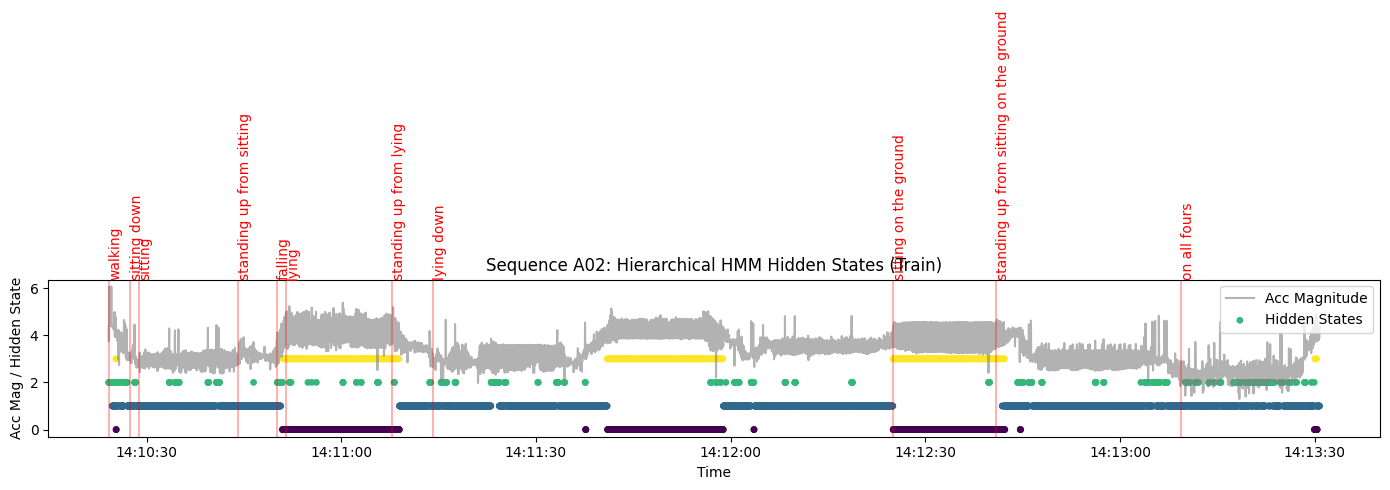

In [38]:
# Pick first sequence from the train nested HMMs
seq_name = list(nested_hmms.keys())[0]  
df_seq = train_df[train_df['sequence_name'] == seq_name].copy()

# Use only the training data portion
df_seq = df_seq[df_seq['sequence_name'].isin(nested_hmms.keys())]

obs = df_seq[feature_cols].values
hidden_states = nested_hmms[seq_name].predict(obs)
df_seq['hidden_state'] = hidden_states

# Map hidden states to activity by mean acc_mag
state_activity_map = df_seq.groupby(['hidden_state', 'activity'])['acc_mag'].mean().unstack(fill_value=0)
print("Mean acc_mag per hidden state per activity:")
print(state_activity_map)

# Plot acceleration magnitude with hidden states overlayed
plt.figure(figsize=(14,5))

# Acceleration magnitude line
plt.plot(df_seq['date_time'], df_seq['acc_mag'], label='Acc Magnitude', color='gray', alpha=0.6)

# Hidden states as scatter
plt.scatter(df_seq['date_time'], df_seq['hidden_state'], c=df_seq['hidden_state'],
            cmap='viridis', s=15, label='Hidden States')

# Mark activity transitions
for act in df_seq['activity'].unique():
    act_df = df_seq[df_seq['activity'] == act]
    start_time = act_df['date_time'].iloc[0]
    plt.axvline(x=start_time, color='red', alpha=0.3)
    plt.text(start_time, df_seq['acc_mag'].max()*1.05, act,
             rotation=90, verticalalignment='bottom', color='red', fontsize=10)

plt.title(f'Sequence {seq_name}: Hierarchical HMM Hidden States (Train)')
plt.xlabel('Time')
plt.ylabel('Acc Mag / Hidden State')
plt.legend()
plt.tight_layout()
plt.show()

### **B. Activity-level Approach**

#### 1. 4-D approch

We first built a model with four sensor data and the accelaration
xt​=(magAL​,magAR​,magCH​,magBELT​);

We used the magnitude of acceleration from four sensors as the input features. Missing values were forward- and backward-filled per sequence.

Each activity sequence was segmented into contiguous chunks of the same activity. These chunks were standardized using a StandardScaler, and per-activity HMMs were trained using the chunks’ 4-dimensional acceleration data. During testing, a Leave-One-Subject-Out (LOSO) cross-validation was performed: the model predicts each left-out sequence chunk by computing HMM log-likelihoods for all activities and selecting the activity with the highest likelihood. Falling probabilities were derived from the softmax of log-likelihoods across activities.


In [39]:
df.head()

,sequence_name,tag_id,timestamp,date_time,x,y,z,activity,body_position,label,acc_mag
0,A01,010-000-024-033,633790226051280329,2009-05-27 14:03:25.127,4.062931,1.892434,0.507425,walking,ANKLE_LEFT,0,4.510676
1,A01,020-000-033-111,633790226051820913,2009-05-27 14:03:25.183,4.291954,1.781140,1.344495,walking,CHEST,0,4.837457
2,A01,020-000-032-221,633790226052091205,2009-05-27 14:03:25.210,4.359101,1.826456,0.968821,walking,BELT,0,4.824554
3,A01,010-000-024-033,633790226052361498,2009-05-27 14:03:25.237,4.087835,1.879999,0.466983,walking,ANKLE_LEFT,0,4.523590
4,A01,010-000-030-096,633790226052631792,2009-05-27 14:03:25.263,4.324462,2.072460,0.488065,walking,ANKLE_RIGHT,0,4.820194


In [40]:
df["activity"].unique()

array(['walking', 'sitting down', 'sitting', 'standing up from sitting',
       'falling', 'lying', 'standing up from lying', 'lying down',
       'sitting on the ground', 'standing up from sitting on the ground',
       'on all fours'], dtype=object)

In [41]:
#Merge activities to reduce the number of classes and increase samples per class for better HMM fitting
activity_map = {
    'walking': 'walking',
    'sitting down': 'sitting',
    'sitting': 'sitting',
    'sitting on the ground': 'sitting',
    'standing up from sitting': 'standing',
    'standing up from lying': 'standing',
    'standing up from sitting on the ground': 'standing',
    'lying': 'lying',
    'lying down': 'lying',
    'falling': 'falling',
    'on all fours': 'on_all_fours'
}

df['activity_merged'] = df['activity'].map(activity_map)

In [42]:
state_map = {'walking':4,'falling':3,'lying':2,'sitting':2,'standing':3,'on_all_fours':2}

In [43]:
# Pivot sensors to columns and fill missing values with forward/backward fill
sensors = ['ANKLE_LEFT', 'ANKLE_RIGHT', 'BELT', 'CHEST']

df_pivot = df.pivot_table(
    index=['sequence_name','date_time','activity_merged'],
    columns='body_position',
    values='acc_mag'
).reset_index()
df_pivot[sensors] = df_pivot.groupby('sequence_name')[sensors].ffill().bfill()
feature_cols = sensors
df_pivot = df_pivot.dropna(subset=feature_cols)


In [44]:
# Predict function
def predict_sequence(X, models):
    scores = {act: model.score(X)/len(X) for act, model in models.items()}
    return max(scores, key=scores.get), scores

# LOSO - Predict on one sequence left out from training
subjects = df_pivot['sequence_name'].unique()
logo = LeaveOneGroupOut()

X_sequences, y_sequences, groups = [], [], []

for seq_name, group in df_pivot.groupby('sequence_name'):
    X_sequences.append(group[feature_cols].values)
    y_sequences.append(group['activity_merged'].values)
    groups.append(seq_name)

X_sequences = np.array(X_sequences, dtype=object)
y_sequences = np.array(y_sequences, dtype=object)
groups = np.array(groups)



In [45]:
# Define fixed colors for each activity
activity_list = ['falling', 'lying', 'sitting', 'standing', 'walking', 'on_all_fours']
color_map = {
    'falling': 'red',
    'lying': 'blue',
    'sitting': 'green',
    'standing': 'orange',
    'walking': 'purple',
    'on_all_fours': 'pink'
}

# Collect timelines and probabilities for all subjects
all_timelines_4d = []

# --- Run LOSO ---
for train_idx, test_idx in logo.split(X_sequences, groups=groups):
    
    # --- Training ---
    train_chunks = []
    train_class_sequences = {}
    for idx in train_idx:
        seq = X_sequences[idx]
        labels = y_sequences[idx]
        
        prev = labels[0]
        start = 0
        for t in range(1, len(labels)):
            if labels[t] != prev:
                chunk = seq[start:t]
                train_class_sequences.setdefault(prev, []).append(chunk)
                train_chunks.append(chunk)
                start = t
                prev = labels[t]
        # Last chunk
        chunk = seq[start:]
        train_class_sequences.setdefault(prev, []).append(chunk)
        train_chunks.append(chunk)
    
    # Scale
    scaler = StandardScaler()
    scaler.fit(np.vstack(train_chunks))
    for act in train_class_sequences:
        train_class_sequences[act] = [scaler.transform(c) for c in train_class_sequences[act]]

    # Train HMMs
    models = {}
    for act, seqs in train_class_sequences.items():
        X_concat = np.vstack(seqs)
        lengths = [len(s) for s in seqs]
        n_states = state_map.get(act, 3)
        model = hmm.GaussianHMM(n_components=n_states, covariance_type='diag', n_iter=200, random_state=42)
        model.fit(X_concat, lengths)
        models[act] = model

    # --- Testing ---
    for idx in test_idx:
        seq = X_sequences[idx]
        labels = y_sequences[idx]
        
        y_true, y_pred = [], []
        falling_probs = []  # store falling probability per chunk
        prev = labels[0]
        start = 0
        
        for t in range(1, len(labels)):
            if labels[t] != prev:
                chunk = seq[start:t]
                chunk_scaled = scaler.transform(chunk)
                
                # --- Get log-likelihoods and probabilities ---
                log_likelihoods = {act: model.score(chunk_scaled) for act, model in models.items()}
                log_vals = np.array(list(log_likelihoods.values()))
                probs = np.exp(log_vals - np.max(log_vals))  # softmax trick
                probs /= probs.sum()
                prob_dict = dict(zip(log_likelihoods.keys(), probs))
                
                y_true.append(prev)
                pred_class = max(log_likelihoods, key=log_likelihoods.get)
                y_pred.append(pred_class)
                falling_probs.append(prob_dict['falling'])  # save falling probability
                
                start = t
                prev = labels[t]
        
        # Last chunk
        chunk = seq[start:]
        chunk_scaled = scaler.transform(chunk)
        log_likelihoods = {act: model.score(chunk_scaled) for act, model in models.items()}
        log_vals = np.array(list(log_likelihoods.values()))
        probs = np.exp(log_vals - np.max(log_vals))
        probs /= probs.sum()
        prob_dict = dict(zip(log_likelihoods.keys(), probs))
        
        y_true.append(prev)
        pred_class = max(log_likelihoods, key=log_likelihoods.get)
        y_pred.append(pred_class)
        falling_probs.append(prob_dict['falling'])
        
        # Save timelines
        all_timelines_4d.append((groups[idx], y_true, y_pred, falling_probs))
        
        # Print classification report
        print(f"\n=== Test Subject: {groups[idx]} ===")
        print(classification_report(y_true, y_pred, zero_division=0))



=== Test Subject: A01 ===
              precision    recall  f1-score   support

     falling       0.60      1.00      0.75         3
       lying       0.67      0.67      0.67         6
on_all_fours       0.00      0.00      0.00         1
     sitting       0.20      0.33      0.25         3
    standing       0.50      0.29      0.36         7
     walking       0.71      0.62      0.67         8

    accuracy                           0.54        28
   macro avg       0.45      0.49      0.45        28
weighted avg       0.56      0.54      0.53        28


=== Test Subject: A02 ===
              precision    recall  f1-score   support

     falling       0.50      0.33      0.40         3
       lying       0.80      0.67      0.73         6
on_all_fours       0.00      0.00      0.00         1
     sitting       0.33      0.67      0.44         3
    standing       1.00      0.57      0.73         7
     walking       0.80      1.00      0.89         8

    accuracy           

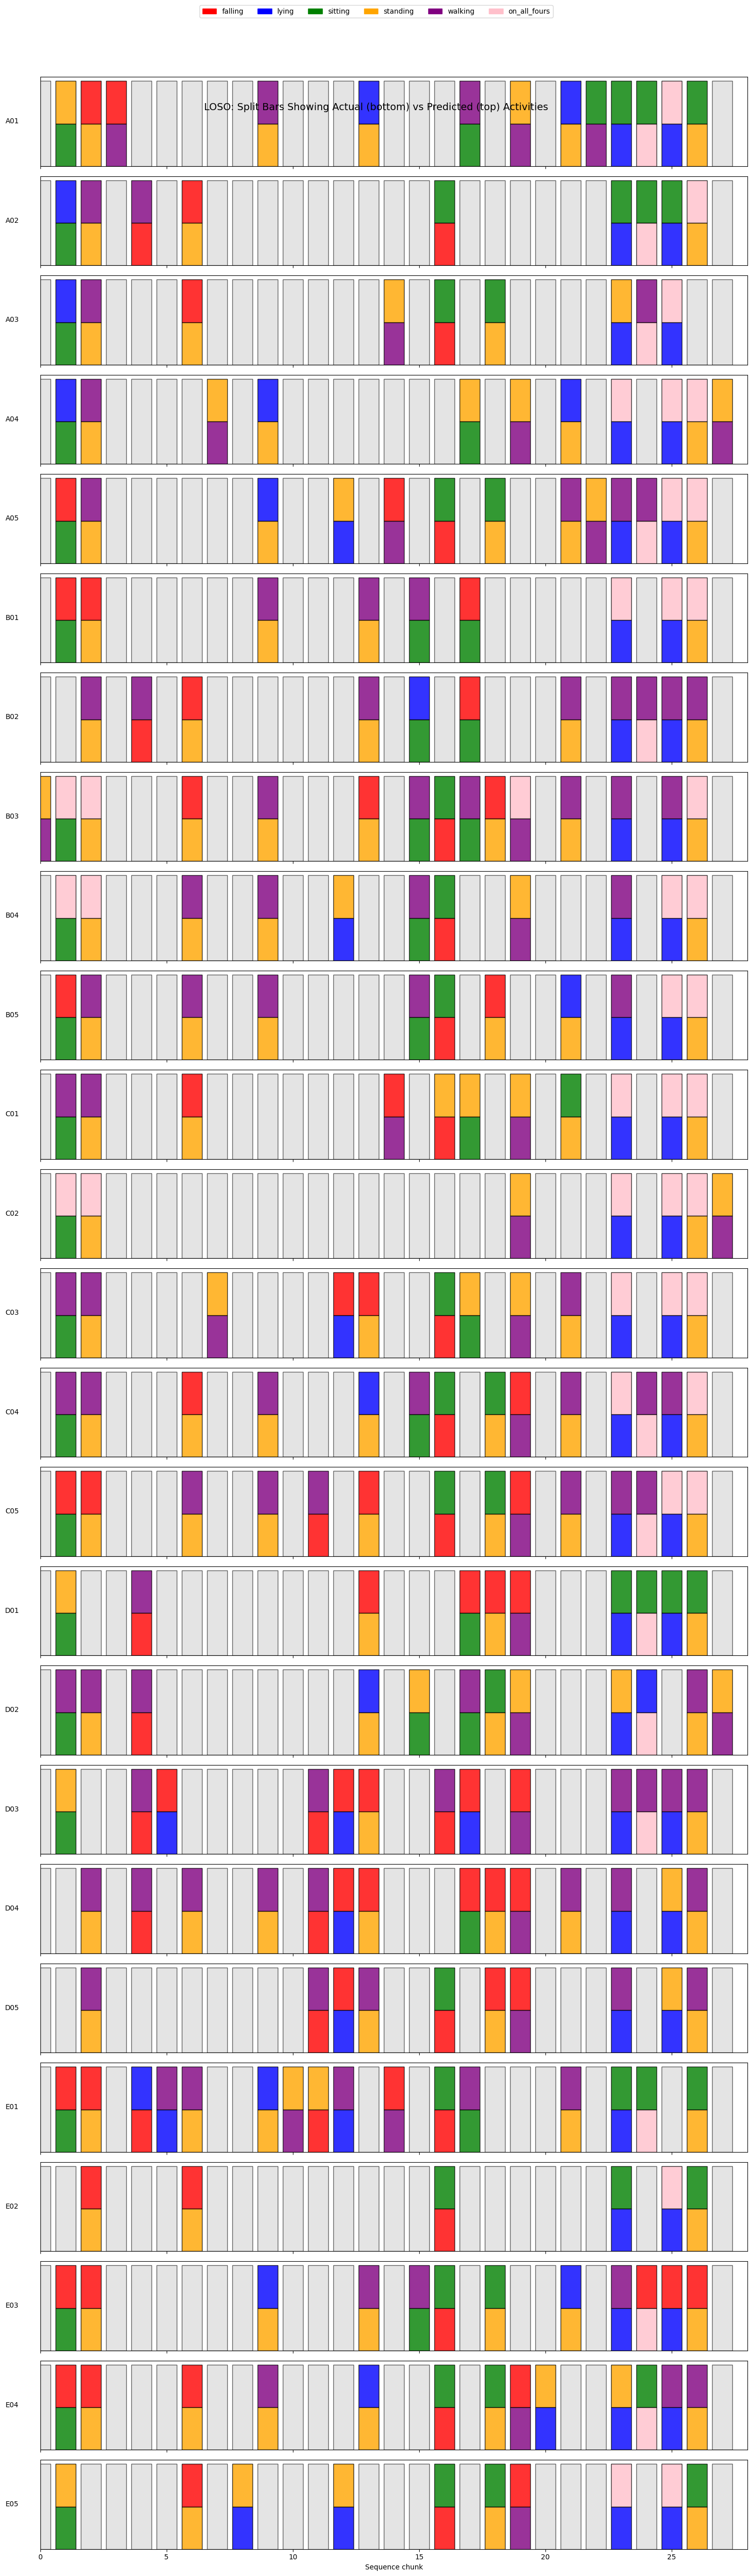

In [46]:
#Plot LOSO: Bars split by predicted (top) and actual (bottom) 
fig, axes = plt.subplots(len(all_timelines_4d), 1, figsize=(15, 2*len(all_timelines_4d)), sharex=True)
if len(all_timelines_4d) == 1:
    axes = [axes]

for ax, (subject, y_true, y_pred, falling_probs) in zip(axes, all_timelines_4d):
    x = np.arange(len(y_true))
    
    for xi, true, pred in zip(x, y_true, y_pred):
        if true != pred:
            # Split bar: bottom = actual, top = predicted
            ax.bar(xi, 0.5, bottom=0, color=color_map[true], edgecolor='k', alpha=0.8)   # bottom half = true
            ax.bar(xi, 0.5, bottom=0.5, color=color_map[pred], edgecolor='k', alpha=0.8) # top half = predicted
        else:
            # Correct prediction = full gray bar
            ax.bar(xi, 1, bottom=0, color='lightgray', edgecolor='k', alpha=0.6)

    ax.set_yticks([])
    ax.set_ylabel(subject, rotation=0, labelpad=40, fontsize=10, va='center')
    ax.set_xlim(0, len(y_true))

# Shared legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[a]) for a in activity_list]
fig.legend(handles, activity_list, loc='upper center', ncol=len(activity_list), bbox_to_anchor=(0.5, 1.02))

plt.xlabel('Sequence chunk')
plt.suptitle('LOSO: Split Bars Showing Actual (bottom) vs Predicted (top) Activities', fontsize=14)
plt.tight_layout()
plt.show()


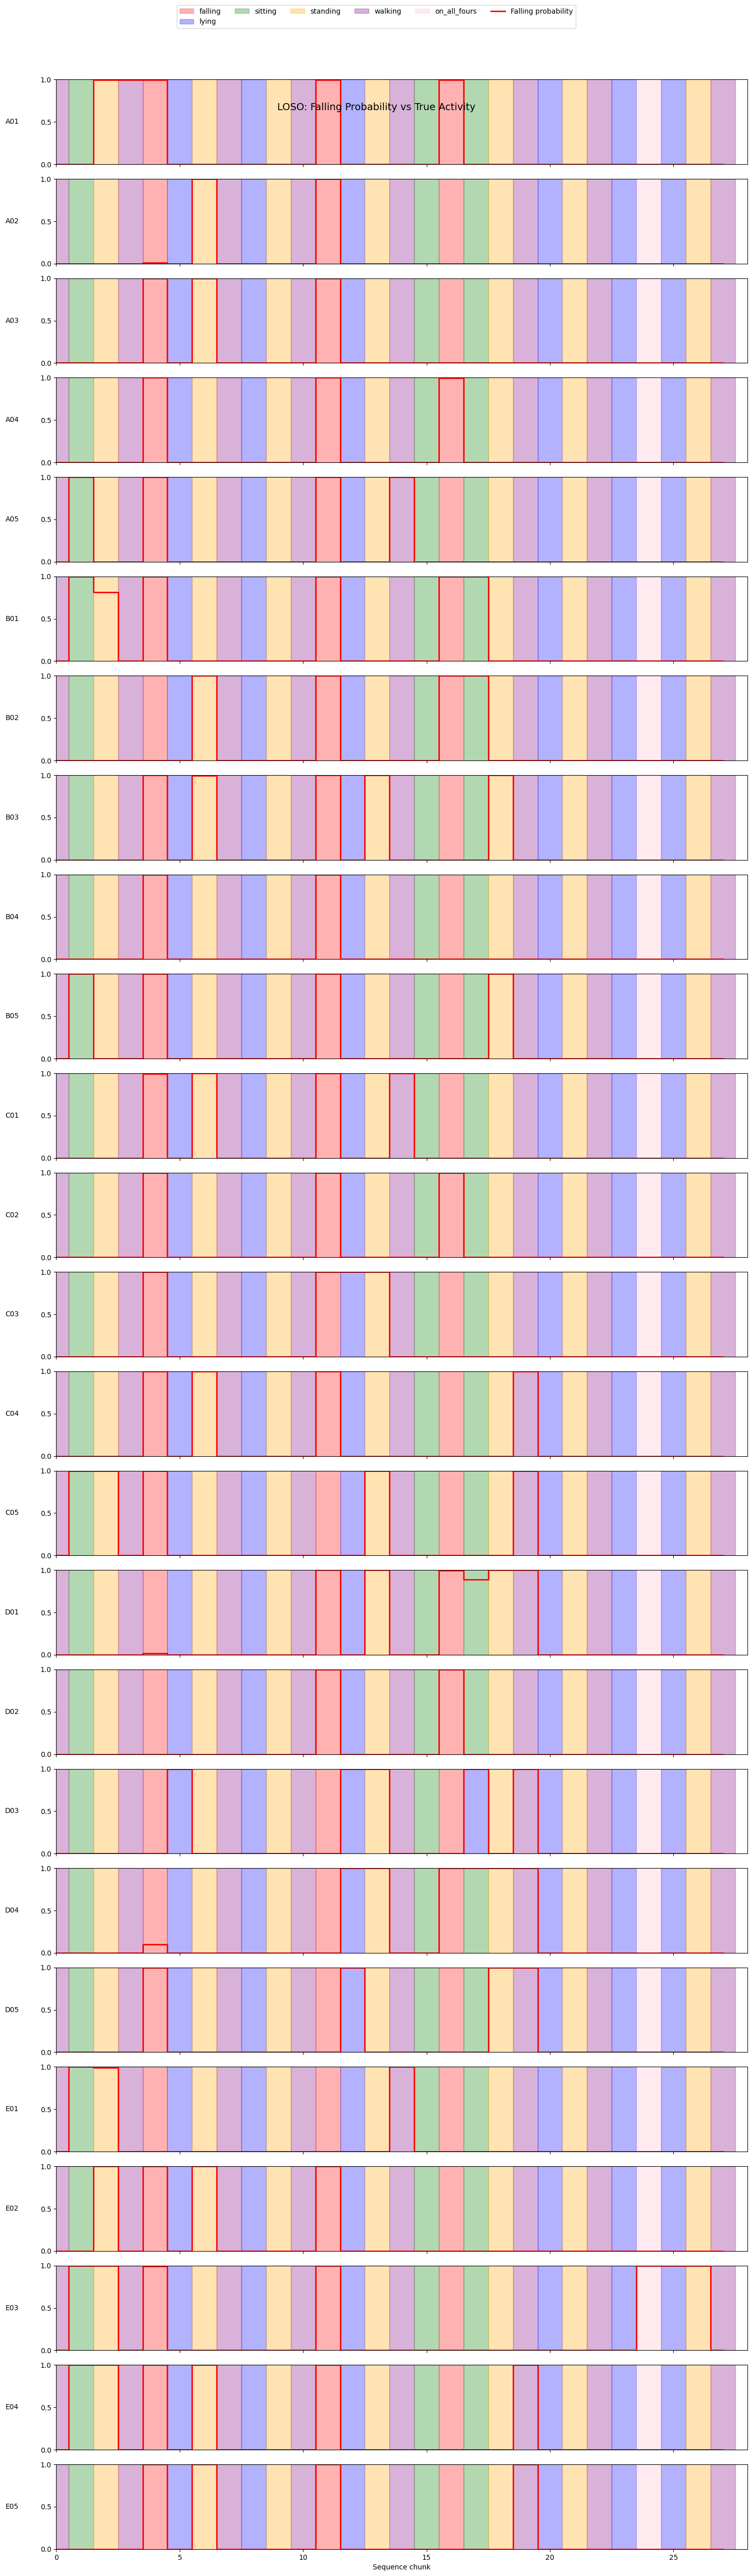

In [47]:
fig, axes = plt.subplots(len(all_timelines_4d), 1, figsize=(15, 2*len(all_timelines_4d)), sharex=True)
if len(all_timelines_4d) == 1:
    axes = [axes]

for ax, (subject, y_true, _, falling_probs) in zip(axes, all_timelines_4d):
    x = np.arange(len(falling_probs))
    
    # plot true activity as colored background
    for xi, act in enumerate(y_true):
        ax.axvspan(xi-0.5, xi+0.5, color=color_map[act], alpha=0.3)

    # plot falling probability
    ax.step(x, falling_probs, where='mid', color='red', linestyle='-', linewidth=2, label='Falling probability')
    
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_ylabel(subject, rotation=0, labelpad=40, fontsize=10, va='center')
    ax.set_xlim(0, len(falling_probs))

# legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[a], alpha=0.3) for a in activity_list]
handles.append(plt.Line2D([0],[0], color='red', lw=2))
labels = activity_list + ['Falling probability']
fig.legend(handles, labels, loc='upper center', ncol=len(activity_list), bbox_to_anchor=(0.5, 1.02))


plt.xlabel('Sequence chunk')
plt.suptitle('LOSO: Falling Probability vs True Activity', fontsize=14)
plt.tight_layout()
plt.show()


### 2. 12-D Approach

For the 12D model, we used all three axes (x, y, z) of four sensors — left ankle, right ankle, belt, and chest — giving a total of 12 features per timestamp. Missing values were forward- and backward-filled within each sequence. Sequences were split into chunks whenever the activity label changed. Each activity had its own HMM trained on the scaled 12D feature sequences. During testing, we applied a LOSO predicting activity per chunk using the normalized log-likelihood from each HMM. We also computed falling probabilities from the softmax of the HMM scores to estimate the likelihood of a fall for each chunk.

In [48]:
#Pivot Sensors to 12D
sensors = ['ANKLE_LEFT','ANKLE_RIGHT','BELT','CHEST']
xyz = ['x','y','z']
feature_cols = [f"{s}_{axis}" for s in sensors for axis in xyz]

# Initialize columns
for col in feature_cols:
    df[col] = np.nan

for s in sensors:
    mask = df['body_position'] == s
    for axis in xyz:
        df.loc[mask, f"{s}_{axis}"] = df.loc[mask, axis]


In [49]:
# Fill missing values
df[feature_cols] = df.groupby('sequence_name')[feature_cols].ffill().bfill()

# Drop remaining NaNs (if any sensor entirely missing)
df = df.dropna(subset=feature_cols)

In [50]:
print(df.columns)

Index(['sequence_name', 'tag_id', 'timestamp', 'date_time', 'x', 'y', 'z',
       'activity', 'body_position', 'label', 'acc_mag', 'activity_merged',
       'ANKLE_LEFT_x', 'ANKLE_LEFT_y', 'ANKLE_LEFT_z', 'ANKLE_RIGHT_x',
       'ANKLE_RIGHT_y', 'ANKLE_RIGHT_z', 'BELT_x', 'BELT_y', 'BELT_z',
       'CHEST_x', 'CHEST_y', 'CHEST_z'],
      dtype='object')


In [51]:
#Build sequences per class
X_sequences, y_sequences, groups = [], [], []

for seq_name, group in df.groupby('sequence_name'):
    X_sequences.append(group[feature_cols].values)
    y_sequences.append(group['activity_merged'].values)  # use merged activity labels
    groups.append(seq_name)  # leave-one-sequence-out

X_sequences = np.array(X_sequences, dtype=object)
y_sequences = np.array(y_sequences, dtype=object)
groups = np.array(groups)


In [52]:
# Define predict function

def predict_sequence(X, models):
    """
    Predicts activity for a sequence chunk using HMM models.
    Returns the predicted activity and the per-class log-likelihood scores.
    """
    scores = {act: model.score(X)/len(X) for act, model in models.items()}  # normalized log-likelihood
    return max(scores, key=scores.get), scores

In [53]:
activity_list = ['falling', 'lying', 'sitting', 'standing', 'walking', 'on_all_fours']
color_map = {
    'falling': 'red',
    'lying': 'blue',
    'sitting': 'green',
    'standing': 'orange',
    'walking': 'purple',
    'on_all_fours': 'pink'
}

logo = LeaveOneGroupOut()
all_timelines_12d = []


# --- Train LOSO ---
for train_idx, test_idx in logo.split(X_sequences, groups=groups):
    # --- Training ---
    train_chunks = []
    train_class_sequences = {}

    for idx in train_idx:
        seq = X_sequences[idx]
        labels = y_sequences[idx]
        prev = labels[0]
        start = 0
        for t in range(1, len(labels)):
            if labels[t] != prev:
                chunk = seq[start:t]
                train_class_sequences.setdefault(prev, []).append(chunk)
                train_chunks.append(chunk)
                start = t
                prev = labels[t]
        # last chunk
        chunk = seq[start:]
        train_class_sequences.setdefault(prev, []).append(chunk)
        train_chunks.append(chunk)

    # --- Scaling ---
    scaler = StandardScaler()
    scaler.fit(np.vstack(train_chunks))
    for act in train_class_sequences:
        train_class_sequences[act] = [scaler.transform(c) for c in train_class_sequences[act]]

    # --- Train HMMs ---
    models = {}
    for act, seqs in train_class_sequences.items():
        X_concat = np.vstack(seqs)
        lengths = [len(s) for s in seqs]
        n_states = state_map.get(act, 3)
        model = hmm.GaussianHMM(n_components=n_states, covariance_type='diag', n_iter=200, random_state=42)
        model.fit(X_concat, lengths)
        models[act] = model

    # --- Testing ---
    for idx in test_idx:
        seq = X_sequences[idx]
        labels = y_sequences[idx]
        y_true, y_pred, falling_probs = [], [], []

        prev = labels[0]
        start = 0
        for t in range(1, len(labels)):
            if labels[t] != prev:
                chunk = seq[start:t]
                chunk_scaled = scaler.transform(chunk)

                # log-likelihoods
                pred_class, scores = predict_sequence(chunk_scaled, models)
                log_vals = np.array(list(scores.values()))
                probs = np.exp(log_vals - np.max(log_vals))  # softmax trick
                probs /= probs.sum()
                prob_dict = dict(zip(scores.keys(), probs))

                y_true.append(prev)
                y_pred.append(pred_class)
                falling_probs.append(prob_dict['falling'])

                start = t
                prev = labels[t]

        # last chunk
        chunk = seq[start:]
        chunk_scaled = scaler.transform(chunk)
        pred_class, scores = predict_sequence(chunk_scaled, models)
        log_vals = np.array(list(scores.values()))
        probs = np.exp(log_vals - np.max(log_vals))
        probs /= probs.sum()
        prob_dict = dict(zip(scores.keys(), probs))

        y_true.append(prev)
        y_pred.append(pred_class)
        falling_probs.append(prob_dict['falling'])

        # Save results
        all_timelines_12d.append((groups[idx], y_true, y_pred, falling_probs))

        # Print classification report per sequence
        print(f"\n=== Test Sequence: {groups[idx]} ===")
        print(classification_report(y_true, y_pred, zero_division=0))



=== Test Sequence: A01 ===
              precision    recall  f1-score   support

     falling       0.50      0.67      0.57         3
       lying       0.80      0.67      0.73         6
on_all_fours       0.33      1.00      0.50         1
     sitting       0.60      1.00      0.75         3
    standing       0.67      0.29      0.40         7
     walking       1.00      1.00      1.00         8

    accuracy                           0.71        28
   macro avg       0.65      0.77      0.66        28
weighted avg       0.75      0.71      0.70        28


=== Test Sequence: A02 ===
              precision    recall  f1-score   support

     falling       0.40      0.67      0.50         3
       lying       1.00      0.17      0.29         6
on_all_fours       0.00      0.00      0.00         1
     sitting       0.60      1.00      0.75         3
    standing       0.50      0.57      0.53         7
     walking       1.00      1.00      1.00         8

    accuracy         

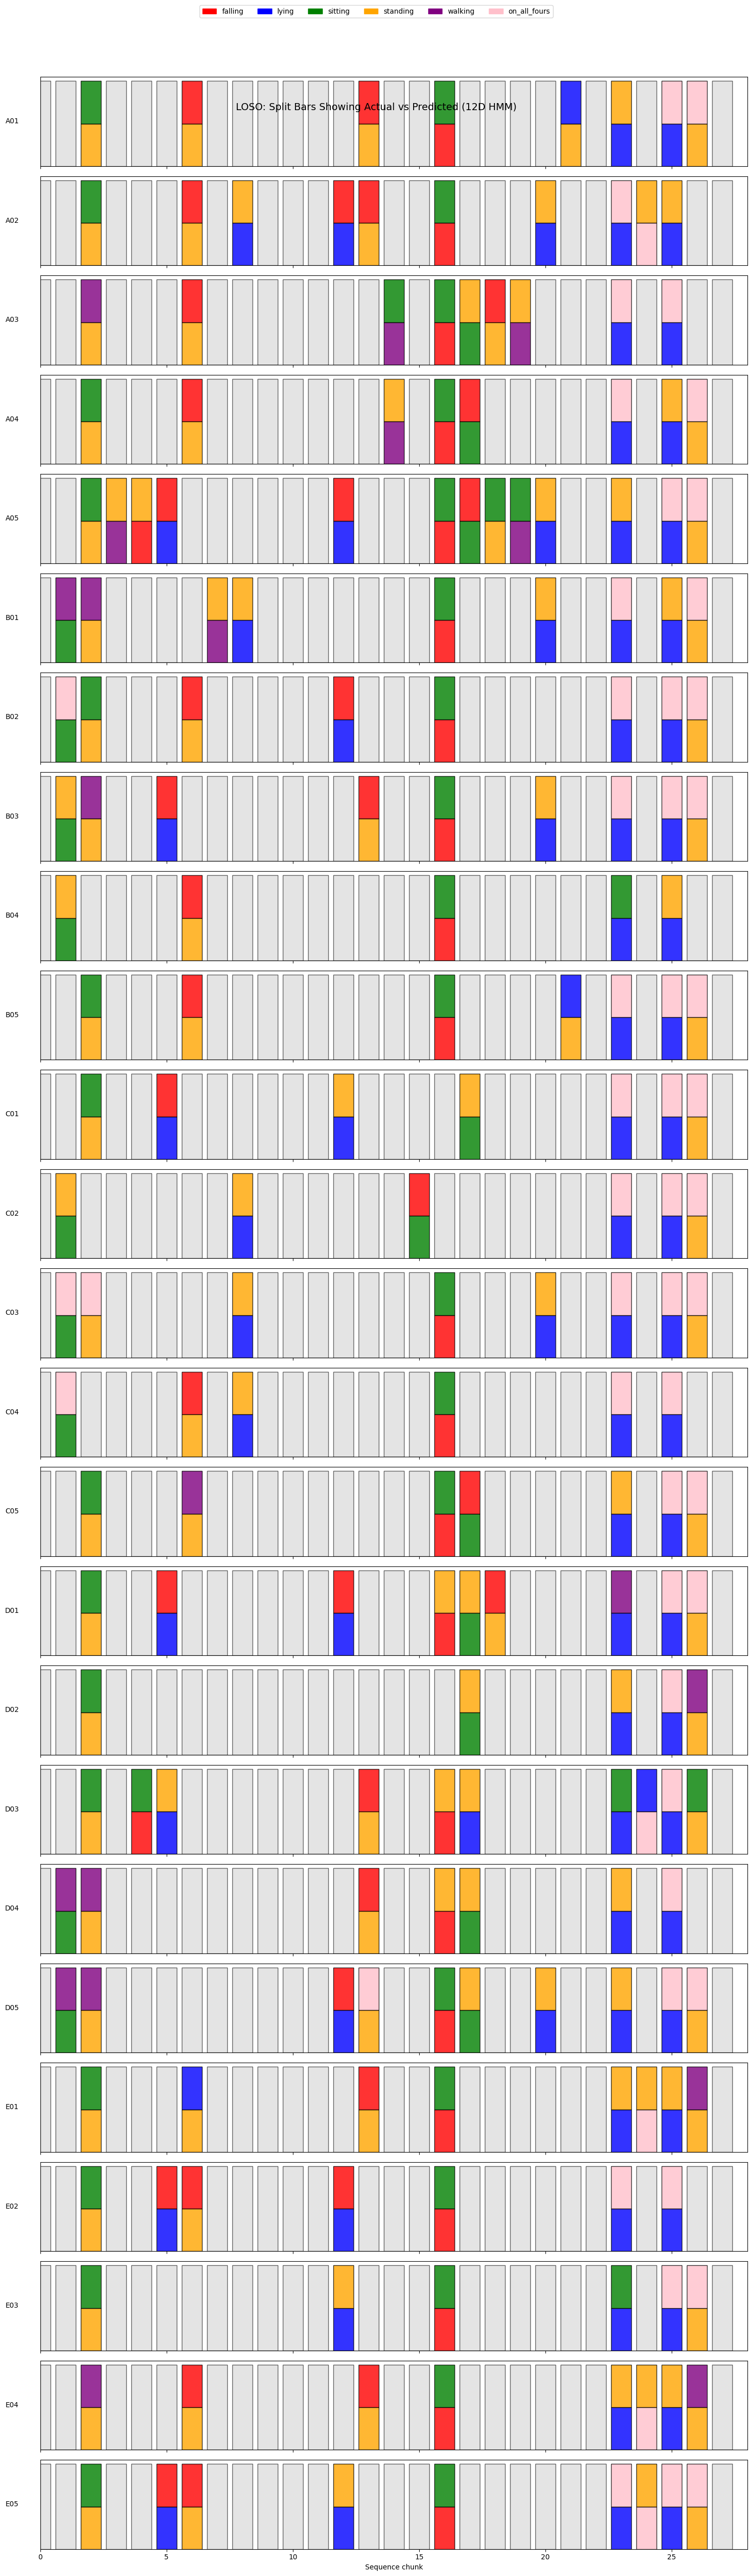

In [54]:
# Plot: Split Bars (actual vs predicted) 
fig, axes = plt.subplots(len(all_timelines_12d), 1, figsize=(15, 2*len(all_timelines_12d)), sharex=True)
if len(all_timelines_12d) == 1:
    axes = [axes]

for ax, (subject, y_true, y_pred, _) in zip(axes, all_timelines_12d):
    x = np.arange(len(y_true))
    for xi, true, pred in zip(x, y_true, y_pred):
        if true != pred:
            # bottom = actual, top = predicted
            ax.bar(xi, 0.5, bottom=0, color=color_map[true], edgecolor='k', alpha=0.8)
            ax.bar(xi, 0.5, bottom=0.5, color=color_map[pred], edgecolor='k', alpha=0.8)
        else:
            ax.bar(xi, 1, bottom=0, color='lightgray', edgecolor='k', alpha=0.6)
    ax.set_yticks([])
    ax.set_ylabel(subject, rotation=0, labelpad=40, fontsize=10, va='center')
    ax.set_xlim(0, len(y_true))

# Shared legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[a]) for a in activity_list]
fig.legend(handles, activity_list, loc='upper center', ncol=len(activity_list), bbox_to_anchor=(0.5,1.02))
plt.xlabel('Sequence chunk')
plt.suptitle('LOSO: Split Bars Showing Actual vs Predicted (12D HMM)', fontsize=14)
plt.tight_layout()
plt.show()


#### Compare 4-d and 12-d models

In [55]:
# Flatten all subjects
y_true_all = []
y_pred_4d_all = []
y_pred_12d_all = []

for (subj, y_true, y_pred, _) in all_timelines_4d:
    y_true_all.extend(y_true)
    y_pred_4d_all.extend(y_pred)

for (subj, _, y_pred, _) in all_timelines_12d:
    y_pred_12d_all.extend(y_pred)

# Overall accuracy
print("4D Accuracy:", accuracy_score(y_true_all, y_pred_4d_all))
print("12D Accuracy:", accuracy_score(y_true_all, y_pred_12d_all))

# Macro F1
print("4D Macro F1:", f1_score(y_true_all, y_pred_4d_all, average='macro'))
print("12D Macro F1:", f1_score(y_true_all, y_pred_12d_all, average='macro'))

# per-class F1
report_4d = classification_report(y_true_all, y_pred_4d_all, zero_division=0)
report_12d = classification_report(y_true_all, y_pred_12d_all, zero_division=0)
print("4D Report:\n", report_4d)
print("12D Report:\n", report_12d)

4D Accuracy: 0.5914285714285714
12D Accuracy: 0.7157142857142857
4D Macro F1: 0.5275596338754234
12D Macro F1: 0.6538855789379351
4D Report:
               precision    recall  f1-score   support

     falling       0.44      0.61      0.51        75
       lying       0.83      0.60      0.69       151
on_all_fours       0.24      0.48      0.32        25
     sitting       0.45      0.46      0.45        74
    standing       0.63      0.35      0.45       175
     walking       0.65      0.85      0.74       200

    accuracy                           0.59       700
   macro avg       0.54      0.56      0.53       700
weighted avg       0.63      0.59      0.59       700

12D Report:
               precision    recall  f1-score   support

     falling       0.59      0.68      0.63        75
       lying       0.95      0.48      0.64       151
on_all_fours       0.28      0.80      0.41        25
     sitting       0.57      0.74      0.64        74
    standing       0.68      0.